# 컴퓨터 가격 예측 (머신러닝 + 딥러닝)
### 시나리오: 컴퓨터 사양(CPU, GPU, RAM, 저장장치 등)을 기반으로 가격(price)을 예측

**분석 흐름**
1. 데이터 탐색 (EDA)
2. 데이터 전처리 (결측치, 인코딩, 스케일링)
3. 머신러닝 모델링 (선형회귀, 랜덤포레스트, XGBoost)
4. 모델 평가 및 비교
5. 딥러닝 모델링 (Keras)

In [1]:
# ========================================
# 1. 라이브러리 임포트
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 주피터 노트북 그래프 출력
%matplotlib inline

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


---
## 1단계: 데이터 탐색 (EDA)

In [2]:
# 데이터 로드
df = pd.read_csv('pandas/data/computer_prices_all.csv')
print(f'데이터 크기: {df.shape[0]:,}행 x {df.shape[1]}열')
df.head()

데이터 크기: 100,000행 x 33열


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
# 데이터 타입 및 결측치 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [4]:
# 수치형 컬럼 기초 통계
df.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [5]:
# 결측치 확인
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

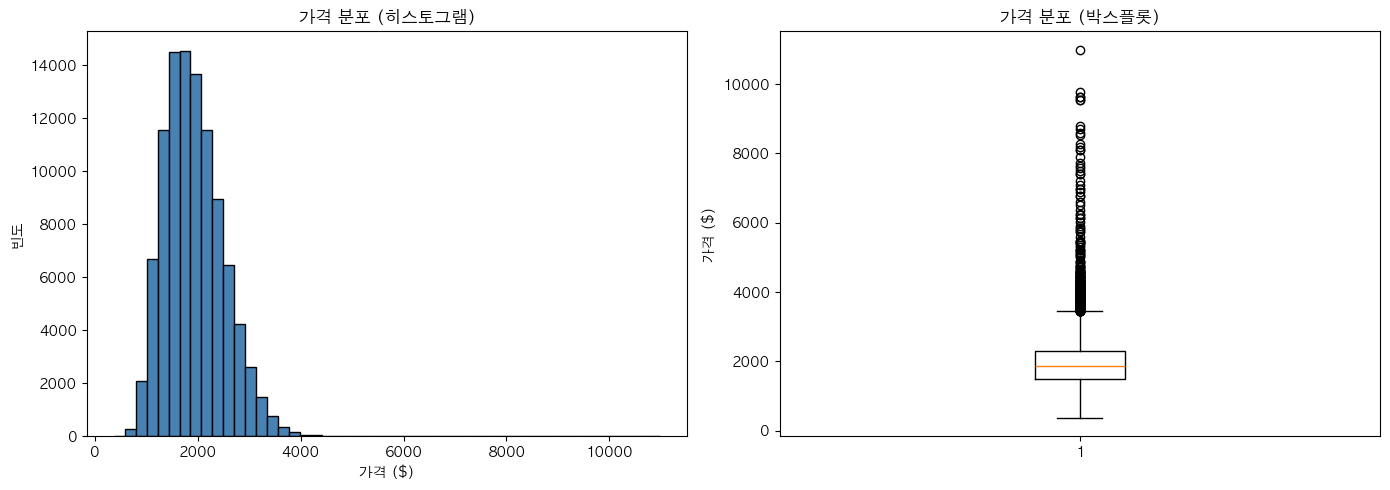

평균 가격: $1,928.76
중앙값 가격: $1,863.99


In [6]:
# 타겟 변수(price) 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('가격 분포 (히스토그램)')
axes[0].set_xlabel('가격 ($)')
axes[0].set_ylabel('빈도')

# 박스플롯
axes[1].boxplot(df['price'], vert=True)
axes[1].set_title('가격 분포 (박스플롯)')
axes[1].set_ylabel('가격 ($)')

plt.tight_layout()
plt.show()

print(f"평균 가격: ${df['price'].mean():,.2f}")
print(f"중앙값 가격: ${df['price'].median():,.2f}")

In [7]:
# 범주형 컬럼 확인
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'범주형 컬럼 ({len(cat_cols)}개): {cat_cols}')

for col in cat_cols:
    print(f'\n[{col}] 고유값 수: {df[col].nunique()}')
    print(df[col].value_counts().head(5))

범주형 컬럼 (13개): ['device_type', 'brand', 'model', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'resolution', 'wifi']

[device_type] 고유값 수: 2
device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64

[brand] 고유값 수: 10
brand
Lenovo    15992
HP        14114
Dell      14005
Apple     11915
ASUS      10159
Name: count, dtype: int64

[model] 고유값 수: 99036
model
Lenovo Think 0V5    3
HP Creator R41      3
ASUS Slim R6S       3
Acer Creator 3U0    3
Dell Think QJA      3
Name: count, dtype: int64

[os] 고유값 수: 4
os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64

[form_factor] 고유값 수: 10
form_factor
Mainstream    17819
Gaming        16876
ATX           15597
Ultrabook     13236
Micro-ATX      8672
Name: count, dtype: int64

[cpu_brand] 고유값 수: 3
cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64

[cpu_model] 고유값 수: 26971
cpu_model
Apple M2 Pro    

In [8]:
# 주요 수치형 컬럼과 가격의 상관관계
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()['price'].sort_values(ascending=False)
print('가격과의 상관관계:')
print(corr)

가격과의 상관관계:
price                  1.000000
gpu_tier               0.762875
cpu_tier               0.759196
ram_gb                 0.758654
cpu_cores              0.720464
cpu_threads            0.577503
cpu_base_ghz           0.529910
cpu_boost_ghz          0.508507
vram_gb                0.305017
battery_wh             0.147212
charger_watts          0.126309
release_year           0.089721
storage_gb             0.088937
refresh_hz             0.077244
bluetooth              0.002076
warranty_months       -0.002138
storage_drive_count   -0.082437
weight_kg             -0.130727
psu_watts             -0.140530
display_size_in       -0.143405
Name: price, dtype: float64


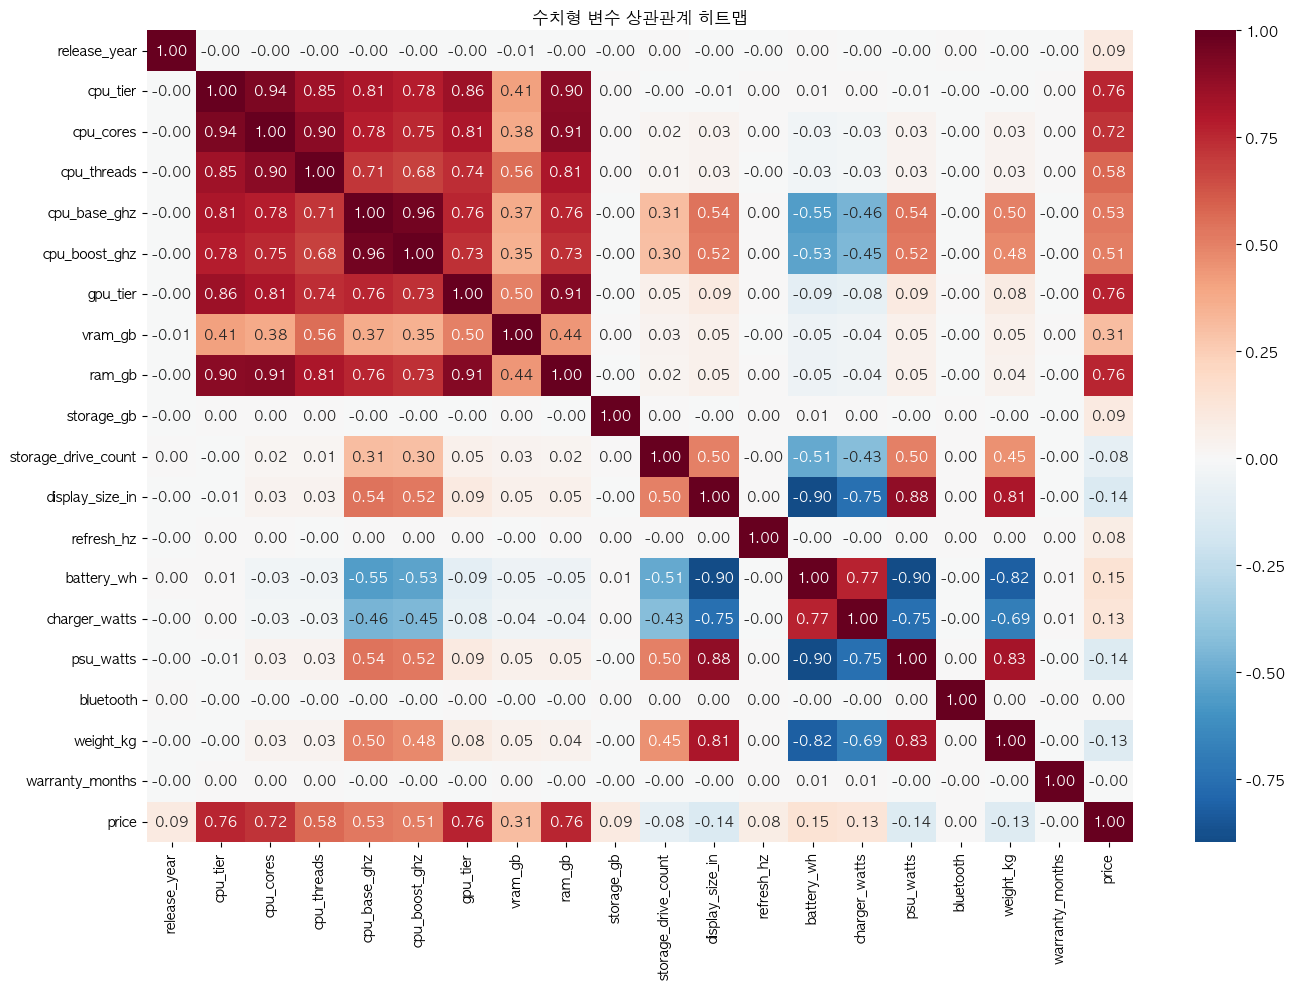

In [9]:
# 상관관계 히트맵
plt.figure(figsize=(14, 10))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('수치형 변수 상관관계 히트맵')
plt.tight_layout()
plt.show()

---
## 2단계: 데이터 전처리

In [10]:
# 전처리용 복사본 생성
data = df.copy()

# model, cpu_model, gpu_model은 고유값이 너무 많아 제거
# (모델명은 가격 예측에 직접 사용하기 어려움)
drop_cols = ['model', 'cpu_model', 'gpu_model']
data = data.drop(columns=drop_cols)
print(f'고유값 과다 컬럼 제거: {drop_cols}')
print(f'남은 컬럼 수: {data.shape[1]}')

고유값 과다 컬럼 제거: ['model', 'cpu_model', 'gpu_model']
남은 컬럼 수: 30


In [11]:
# 결측치 처리
# 수치형: 중앙값으로 대체 (이상치에 강건)
# 범주형: 최빈값으로 대체
for col in data.columns:
    if data[col].isnull().sum() > 0:
        if data[col].dtype == 'object':
            data[col].fillna(data[col].mode()[0], inplace=True)
            print(f'[{col}] 범주형 → 최빈값으로 대체')
        else:
            data[col].fillna(data[col].median(), inplace=True)
            print(f'[{col}] 수치형 → 중앙값으로 대체')

print(f'\n남은 결측치: {data.isnull().sum().sum()}')


남은 결측치: 0


In [12]:
# 범주형 변수 원-핫 인코딩
cat_cols = data.select_dtypes(include='object').columns.tolist()
print(f'인코딩 대상 컬럼: {cat_cols}')

data = pd.get_dummies(data, columns=cat_cols, dtype=int)
print(f'인코딩 후 컬럼 수: {data.shape[1]}')
data.head()

인코딩 대상 컬럼: ['device_type', 'brand', 'os', 'form_factor', 'cpu_brand', 'gpu_brand', 'storage_type', 'display_type', 'resolution', 'wifi']
인코딩 후 컬럼 수: 73


,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,...,resolution_1920x1080,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 5,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
0,2022,3,12,24,2.8,3.8,2,6,16,1024,...,0,1,0,0,0,0,0,1,0,0
1,2022,4,12,24,2.6,3.6,4,10,64,512,...,1,0,0,0,0,0,0,1,0,0
2,2024,2,8,16,2.6,3.6,1,4,8,512,...,0,0,0,0,1,0,0,1,0,0
3,2024,2,6,12,2.6,3.6,2,6,16,512,...,0,0,0,0,1,0,0,1,0,0
4,2024,5,16,32,2.8,3.9,5,12,96,256,...,0,0,1,0,0,0,0,1,0,0


In [13]:
# 독립변수(X)와 종속변수(y) 분리
X = data.drop(columns=['price'])    # price를 제외한 컬럼을 X에
y = data['price']                   # price를 y에

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (100000, 72)
y shape: (100000,)


In [14]:
# Train / Test 분할 (80:20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]:,}개')
print(f'Test:  {X_test.shape[0]:,}개')

Train: 80,000개
Test:  20,000개


In [15]:
# 스케일링 (StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train으로 fit + transform
X_test_scaled = scaler.transform(X_test)         # test는 transform만!

print('스케일링 완료')
print(f'Train 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}')
print(f'Test 평균: {X_test_scaled.mean():.4f}, 표준편차: {X_test_scaled.std():.4f}')

스케일링 완료
Train 평균: -0.0000, 표준편차: 1.0000
Test 평균: 0.0004, 표준편차: 1.0006


---
## 3단계: 머신러닝 모델링

In [16]:
# 평가 지표 함수 정의
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
'''
MSE	    Mean Squared Error	                        평균 제곱 오차
RMSE	Root Mean Squared Error	                    평균 제곱근 오차(직관적)
MAE     Mean Absolute Error	                        평균 절대 오차 (오차의 절대값)
R²	    R-squared (Coefficient of Determination)	결정 계수, 모델이 데이터를 얼마나 잘 설명하는지 (0~1, 1에 가까울수록 좋음)
'''

def evaluate_model(name, y_true, y_pred):
    """모델 성능 평가 결과를 출력하고 딕셔너리로 반환"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'[{name}]')
    print(f'  RMSE: {rmse:,.2f}')
    print(f'  MAE:  {mae:,.2f}')
    print(f'  R2:   {r2:.4f}')
    print()
    
    return {'모델': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2': round(r2, 4)}

# 결과 저장용 리스트
results = []

### 3-1. 선형 회귀 (Linear Regression)

In [17]:
from sklearn.linear_model import LinearRegression

# 모델 생성 및 학습
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 예측
y_pred_lr = lr.predict(X_test_scaled)

# 평가
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

[Linear Regression]
  RMSE: 202.88
  MAE:  143.27
  R2:   0.8754



### 3-2. 랜덤 포레스트 (Random Forest)

In [18]:
from sklearn.ensemble import RandomForestRegressor

# 모델 생성 및 학습
# n_estimators: 트리 개수, max_depth: 트리 최대 깊이
rf = RandomForestRegressor(
    n_estimators=300,   # 트리 100개
    max_depth=None,     # 최대 깊이 15
    random_state=42,
    n_jobs=-1           # 모든 CPU 코어 사용
)
rf.fit(X_train_scaled, y_train)

# 예측
y_pred_rf = rf.predict(X_test_scaled)

# 평가
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

[Random Forest]
  RMSE: 224.59
  MAE:  158.26
  R2:   0.8473



### 3-3. XGBoost

In [19]:
from xgboost import XGBRegressor

# 모델 생성 및 학습
xgb = XGBRegressor(
    n_estimators=500,       # 부스팅 반복 횟수 (200)
    max_depth=12,            # 트리 최대 깊이 (8)
    learning_rate=0.05,      # 학습률 (작을수록 정밀하지만 느림) (0.1)
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)

# 예측
y_pred_xgb = xgb.predict(X_test_scaled)

# 평가
results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))

[XGBoost]
  RMSE: 215.02
  MAE:  148.66
  R2:   0.8600



### 3-4. XGBoost 성능 개선 (하이퍼파라미터 튜닝)

In [20]:
# ========================================
# XGBoost 성능이 낮은 이유:
#   1. max_depth=8 → 트리가 얕아서 수백 개 피처의 복잡한 패턴을 못 잡음
#   2. n_estimators=200 → 반복 횟수 부족
#   3. learning_rate=0.1 → 학습률이 높아 세밀한 학습 부족
# ========================================

# 개선된 XGBoost
xgb_tuned = XGBRegressor(
    n_estimators=500,       # 200 → 500 (반복 횟수 증가)
    max_depth=12,           # 8 → 12 (더 깊은 트리로 복잡한 패턴 학습)
    learning_rate=0.05,     # 0.1 → 0.05 (더 세밀하게 학습)
    subsample=0.8,          # 데이터의 80%만 샘플링 (과적합 방지)
    colsample_bytree=0.8,   # 피처의 80%만 사용 (과적합 방지)
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train_scaled, y_train)

# 예측
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)

# 평가
results.append(evaluate_model('XGBoost (Tuned)', y_test, y_pred_xgb_tuned))

[XGBoost (Tuned)]
  RMSE: 210.36
  MAE:  147.01
  R2:   0.8660



In [21]:
# 기본 XGBoost vs 튜닝된 XGBoost 비교
print('[ 기본 XGBoost ]')
print(f'  max_depth=8, n_estimators=200, learning_rate=0.1')
print(f'  R2: {r2_score(y_test, y_pred_xgb):.4f}')
print()
print('[ 튜닝된 XGBoost ]')
print(f'  max_depth=12, n_estimators=500, learning_rate=0.05')
print(f'  R2: {r2_score(y_test, y_pred_xgb_tuned):.4f}')
print()
print(f'성능 향상: R2 {r2_score(y_test, y_pred_xgb_tuned) - r2_score(y_test, y_pred_xgb):.4f} 증가')

[ 기본 XGBoost ]
  max_depth=8, n_estimators=200, learning_rate=0.1
  R2: 0.8600

[ 튜닝된 XGBoost ]
  max_depth=12, n_estimators=500, learning_rate=0.05
  R2: 0.8660

성능 향상: R2 0.0060 증가


---
## 4단계: 머신러닝 모델 비교

In [22]:
# 모델별 성능 비교 테이블
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('R2', ascending=False).reset_index(drop=True)
print('머신러닝 모델 성능 비교')
df_results

머신러닝 모델 성능 비교


,모델,RMSE,MAE,R2
0,Linear Regression,202.88,143.27,0.8754
1,XGBoost (Tuned),210.36,147.01,0.8660
2,XGBoost,215.02,148.66,0.8600
3,Random Forest,224.59,158.26,0.8473


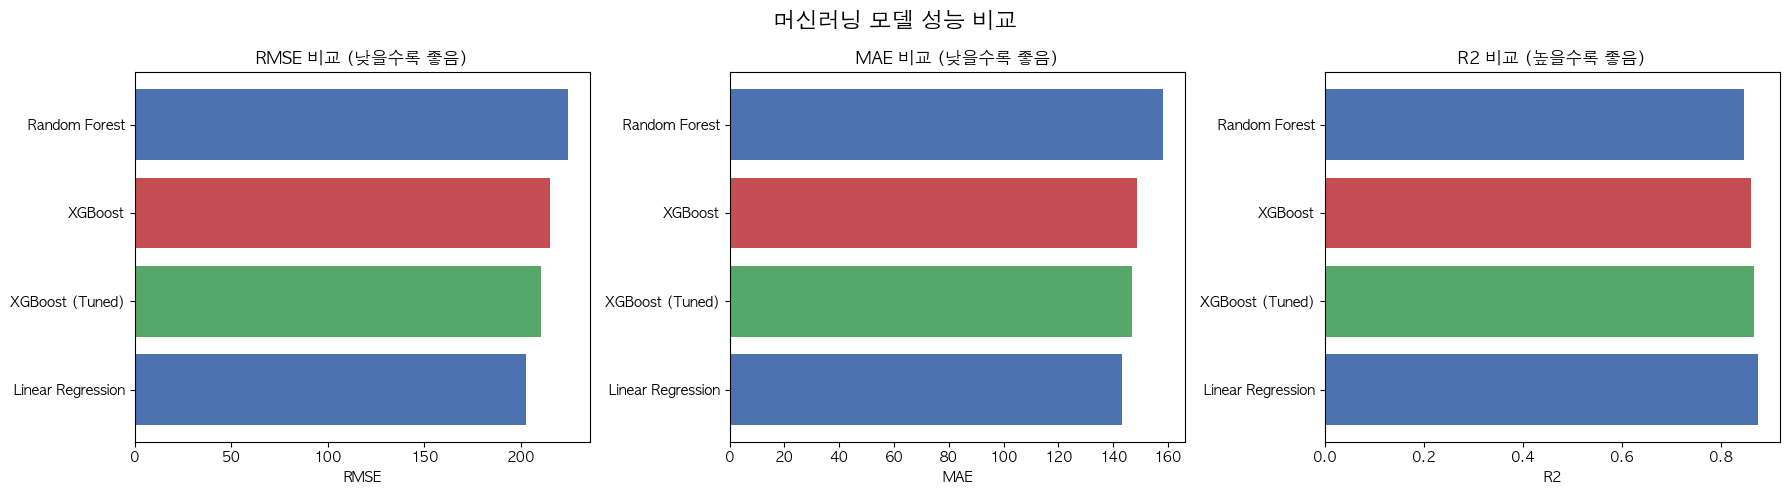

In [23]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = df_results['모델']
colors = ['#4C72B0', '#55A868', '#C44E52']

# RMSE 비교
axes[0].barh(models, df_results['RMSE'], color=colors)
axes[0].set_title('RMSE 비교 (낮을수록 좋음)')
axes[0].set_xlabel('RMSE')

# MAE 비교
axes[1].barh(models, df_results['MAE'], color=colors)
axes[1].set_title('MAE 비교 (낮을수록 좋음)')
axes[1].set_xlabel('MAE')

# R2 비교
axes[2].barh(models, df_results['R2'], color=colors)
axes[2].set_title('R2 비교 (높을수록 좋음)')
axes[2].set_xlabel('R2')

plt.suptitle('머신러닝 모델 성능 비교', fontsize=16)
plt.tight_layout()
plt.show()

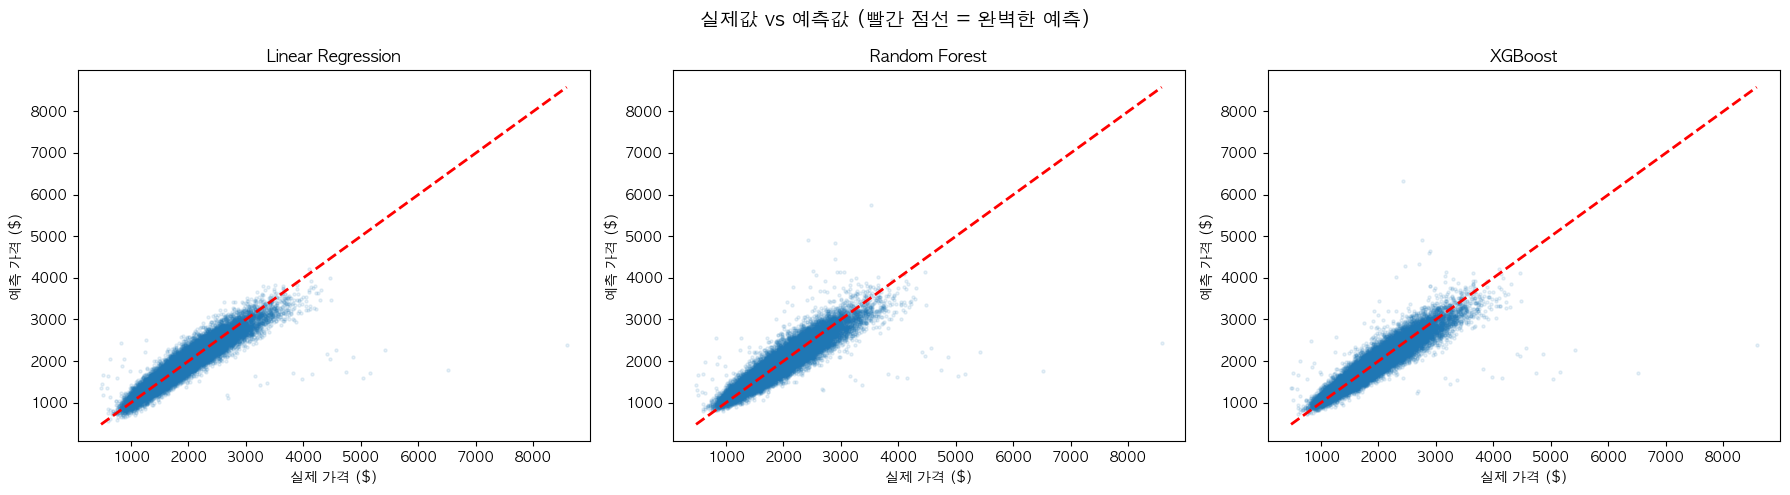

In [24]:
# 실제값 vs 예측값 산점도 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

preds = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.1, s=5)
    # 빨간 대각선 = 완벽한 예측 기준선
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(name)
    ax.set_xlabel('실제 가격 ($)')
    ax.set_ylabel('예측 가격 ($)')

plt.suptitle('실제값 vs 예측값 (빨간 점선 = 완벽한 예측)', fontsize=14)
plt.tight_layout()
plt.show()

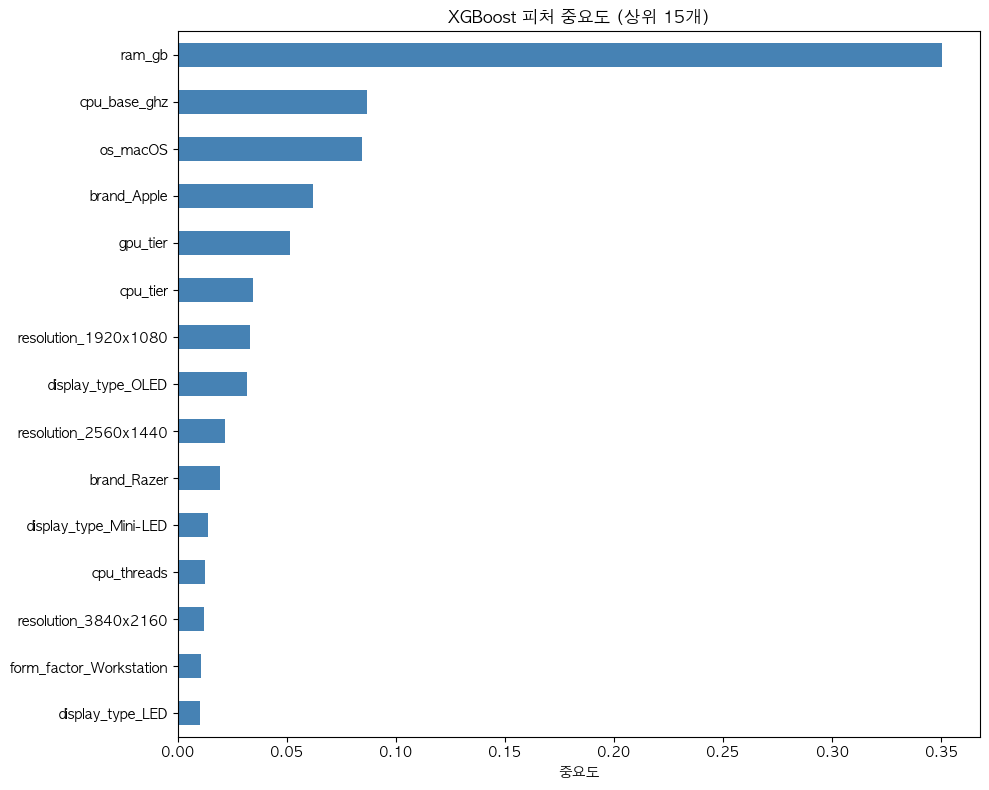

In [25]:
# XGBoost 피처 중요도 (상위 15개)
feature_importance = pd.Series(
    xgb.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('XGBoost 피처 중요도 (상위 15개)')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

---
## 5단계: 딥러닝 모델링 (Keras)

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow 버전: {tf.__version__}')

TensorFlow 버전: 2.15.0


In [27]:
# 딥러닝 모델 구성
input_dim = X_train_scaled.shape[1]  # 입력 차원 = 피처 수

model = Sequential([
    # 첫 번째 은닉층: 256개 뉴런, ReLU 활성화 함수
    Dense(256, activation='relu', input_dim=input_dim),
    BatchNormalization(),        # 배치 정규화 (학습 안정화)
    Dropout(0.3),                # 30% 드롭아웃 (과적합 방지)
    
    # 두 번째 은닉층: 128개 뉴런
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 세 번째 은닉층: 64개 뉴런
    Dense(64, activation='relu'),
    Dropout(0.1),
    
    # 출력층: 1개 뉴런 (가격 = 연속형 값이므로 활성화 함수 없음)
    Dense(1)
])

# 모델 컴파일
# 회귀 문제이므로 손실함수: MSE, 평가지표: MAE
model.compile(
    optimizer='adam',       # 옵티마이저: Adam
    loss='mse',            # 손실함수: 평균 제곱 오차
    metrics=['mae']        # 평가지표: 평균 절대 오차
)

# 모델 구조 확인
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               18688     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [28]:
# 조기 종료 콜백 설정
# val_loss가 10 에포크 동안 개선되지 않으면 학습 중단
early_stop = EarlyStopping(
    monitor='val_loss',          # 검증 손실 기준으로 모니터링
    patience=10,                 # 10 에포크 동안 개선 없으면 중단
    restore_best_weights=True    # 가장 좋은 가중치로 복원
)

# 모델 학습
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,              # 최대 100 에포크
    batch_size=256,          # 한 번에 256개씩 학습
    validation_split=0.2,    # 학습 데이터의 20%를 검증용으로 사용
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
250/250 [==============================] - 1s 3ms/step - loss: 3284957.2500 - mae: 1736.7609 - val_loss: 1410004.3750 - val_mae: 1115.9995
Epoch 2/100
250/250 [==============================] - 1s 3ms/step - loss: 658680.3125 - mae: 646.3557 - val_loss: 314089.7812 - val_mae: 488.5822
Epoch 3/100
250/250 [==============================] - 1s 3ms/step - loss: 173911.2344 - mae: 302.0550 - val_loss: 88156.6797 - val_mae: 198.7057
Epoch 4/100
250/250 [==============================] - 1s 3ms/step - loss: 115838.0938 - mae: 246.8056 - val_loss: 52254.0586 - val_mae: 156.1480
Epoch 5/100
250/250 [==============================] - 1s 3ms/step - loss: 92417.7891 - mae: 215.9586 - val_loss: 47727.3008 - val_mae: 147.2042
Epoch 6/100
250/250 [==============================] - 1s 3ms/step - loss: 88038.7031 - mae: 209.0658 - val_loss: 45548.7656 - val_mae: 141.8878
Epoch 7/100
250/250 [==============================] - 1s 3ms/step - loss: 84621.3750 - mae: 203.7489 - val_loss: 45125.

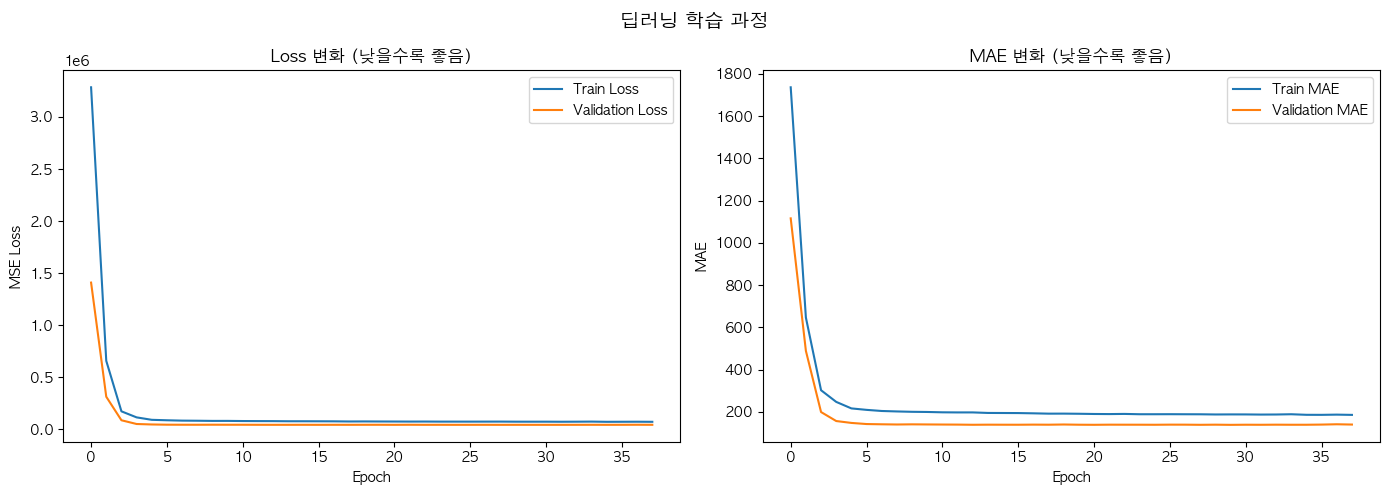

In [29]:
# 학습 과정 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선 (손실 변화)
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss 변화 (낮을수록 좋음)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# MAE 곡선 (오차 변화)
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('MAE 변화 (낮을수록 좋음)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('딥러닝 학습 과정', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# 딥러닝 모델 테스트셋 평가
y_pred_dl = model.predict(X_test_scaled).flatten()

# 평가
results.append(evaluate_model('Deep Learning (Keras)', y_test, y_pred_dl))

625/625 [==============================] - 0s 462us/step
[Deep Learning (Keras)]
  RMSE: 197.59
  MAE:  138.63
  R2:   0.8818



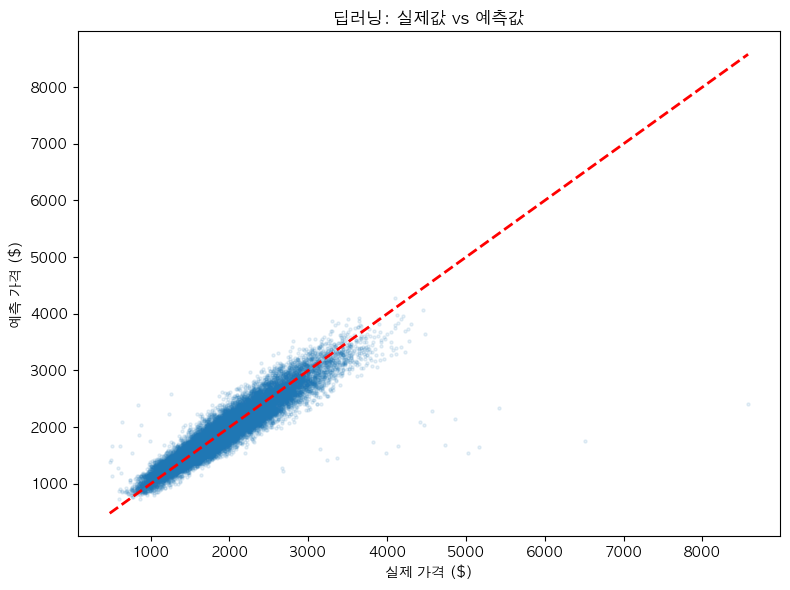

In [31]:
# 딥러닝 실제값 vs 예측값 산점도
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dl, alpha=0.1, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('딥러닝: 실제값 vs 예측값')
plt.xlabel('실제 가격 ($)')
plt.ylabel('예측 가격 ($)')
plt.tight_layout()
plt.show()

---
## 6단계: 전체 모델 최종 비교 (머신러닝 + 딥러닝)

In [32]:
# 머신러닝 + 딥러닝 전체 성능 비교
df_final = pd.DataFrame(results)
df_final = df_final.sort_values('R2', ascending=False).reset_index(drop=True)

print('=' * 55)
print('전체 모델 성능 비교 (머신러닝 + 딥러닝)')
print('=' * 55)
df_final

전체 모델 성능 비교 (머신러닝 + 딥러닝)


,모델,RMSE,MAE,R2
0,Deep Learning (Keras),197.59,138.63,0.8818
1,Linear Regression,202.88,143.27,0.8754
2,XGBoost (Tuned),210.36,147.01,0.8660
3,XGBoost,215.02,148.66,0.8600
4,Random Forest,224.59,158.26,0.8473


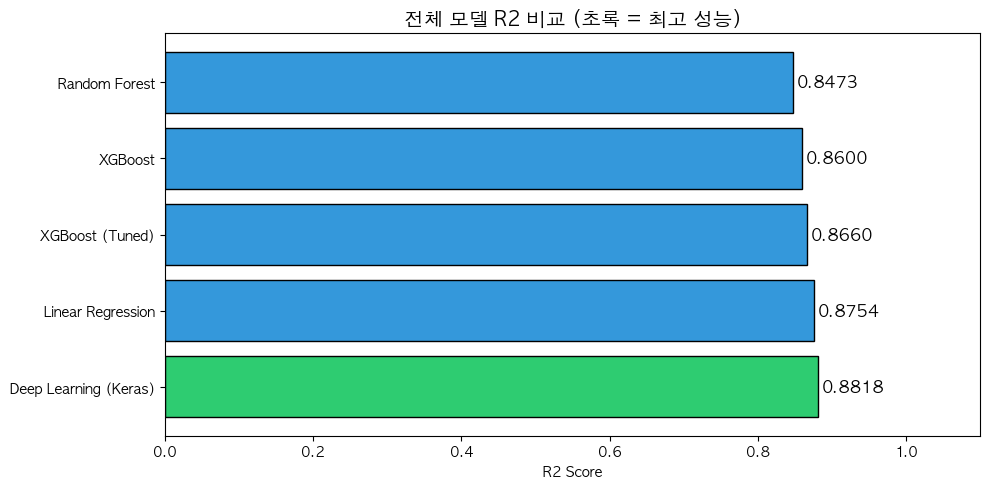


최고 성능 모델: Deep Learning (Keras) (R2=0.8818)


In [33]:
# 전체 모델 R2 비교 시각화
plt.figure(figsize=(10, 5))

# 최고 성능 모델은 초록색으로 강조
colors = ['#2ecc71' if r == df_final['R2'].max() else '#3498db' for r in df_final['R2']]
bars = plt.barh(df_final['모델'], df_final['R2'], color=colors, edgecolor='black')

# 막대 옆에 R2 값 표시
for bar, val in zip(bars, df_final['R2']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=12, fontweight='bold')

plt.title('전체 모델 R2 비교 (초록 = 최고 성능)', fontsize=14)
plt.xlabel('R2 Score')
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

# 최고 성능 모델 출력
best = df_final.iloc[0]
print(f'\n최고 성능 모델: {best["모델"]} (R2={best["R2"]:.4f})')